WEB SCRAPING 

INTRODUCTION - this project aims for web scraping. Web Scraping is a technique used to extract data from websites automatically using programming tools and libraries. In this project, data related to books like title, rating, price and availability is collected from an online book website.The extracted data is then cleaned, organised and analysed to receive insights using visualization.

OBJECTIVE - the objective of this project is to perform web scraping to collect book related data from an online website using Python libraries like Requests, Pandas, Matplotlib and Beautiful Soup. The project also aims to practice HTML parsing, data extraction, data cleaning and visualization. 

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt


url = "https://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text,"html.parser")
books = soup.find_all('article', class_='product_pod')

title_list = []
price_list = []
rating_list = []
availability_list = []
for book in books:
    title = book.h3.a['title'] #extract title
    price = book.find('p',class_='price_color').text   #extract price
    rating = book.find('p')['class'][1]   #extract rating
    availability = book.find('p', class_='instock availability').text.replace('\n',' ').strip() #removes leading and trailing spaces
    
    title_list.append(title)
    price_list.append(price)
    rating_list.append(rating)
    availability_list.append(availability)

df = pd.DataFrame({
    'Title':title_list,
    'Price' : price_list,
    'Rating' : rating_list,
    'Availability' : availability_list
})

pd.set_option('display.max_columns',None) #show all dataframe columns
pd.set_option('display.width',1000) #take output screen width is 1000 characters wide

print("Total Books : ",len(df))

df.to_csv("book_data.csv", index=False)

df['Price'] = df['Price'].str.replace('Â£', '', regex=True)    #removing euro sign, convinient for graph
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.extract(r'(\d+\.\d+)').astype(float)

rating_map = {      #converting rating string to numbers
    'One' : 1,
    'Two' : 2,
    'Three' : 3,
    'Four' : 4,
    'Five' : 5
}
df['Rating'] = df['Rating'].map(rating_map)

df.drop_duplicates(inplace=True)
print(df)


Total Books :  20
                                                Title  Price  Rating Availability
0                                A Light in the Attic  51.77       3     In stock
1                                  Tipping the Velvet  53.74       1     In stock
2                                          Soumission  50.10       1     In stock
3                                       Sharp Objects  47.82       4     In stock
4               Sapiens: A Brief History of Humankind  54.23       5     In stock
5                                     The Requiem Red  22.65       1     In stock
6   The Dirty Little Secrets of Getting Your Dream...  33.34       4     In stock
7   The Coming Woman: A Novel Based on the Life of...  17.93       3     In stock
8   The Boys in the Boat: Nine Americans and Their...  22.60       4     In stock
9                                     The Black Maria  52.15       1     In stock
10     Starving Hearts (Triangular Trade Trilogy, #1)  13.99       2     In stoc

WHAT ALL I DID-
I imported the required libraries like requests, pandas, beautiful soup and matplotlib.
I loaded the url for book scraping and stored its html code.
then I extracted the required class and attributes from the extracted class.
I created four empty lists for title,price,rating and availability and I loaded the values from the site in each of them respectively.
I loaded this data into a dataframe and stored this dataframe as a csv file.
I removed the unrequired symbols and did the necessary conversions using astype.
Then i created a rating map for the books.
I removed the duplicates for better performance of my dataset.

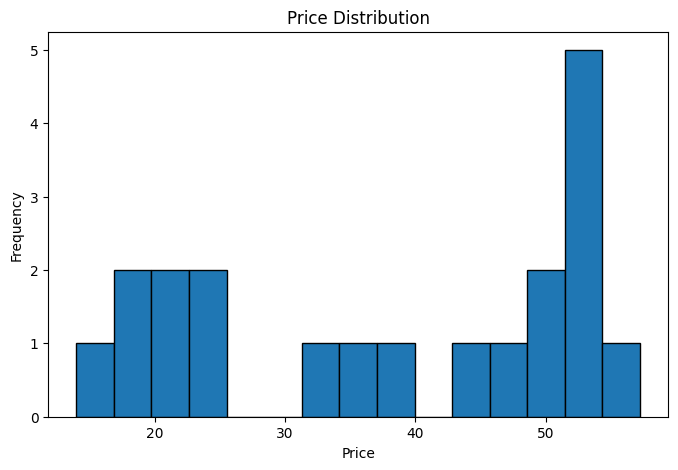

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['Price'],bins=15, edgecolor='black')
plt.title("Price Distribution")
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

OBSERVATIONS - 
this is a price distribution visualisation which tells us each the frequency of books vs price graph.
most of the books are priced above $50.
some books are very expensive almost $60.
displayed by histogram.

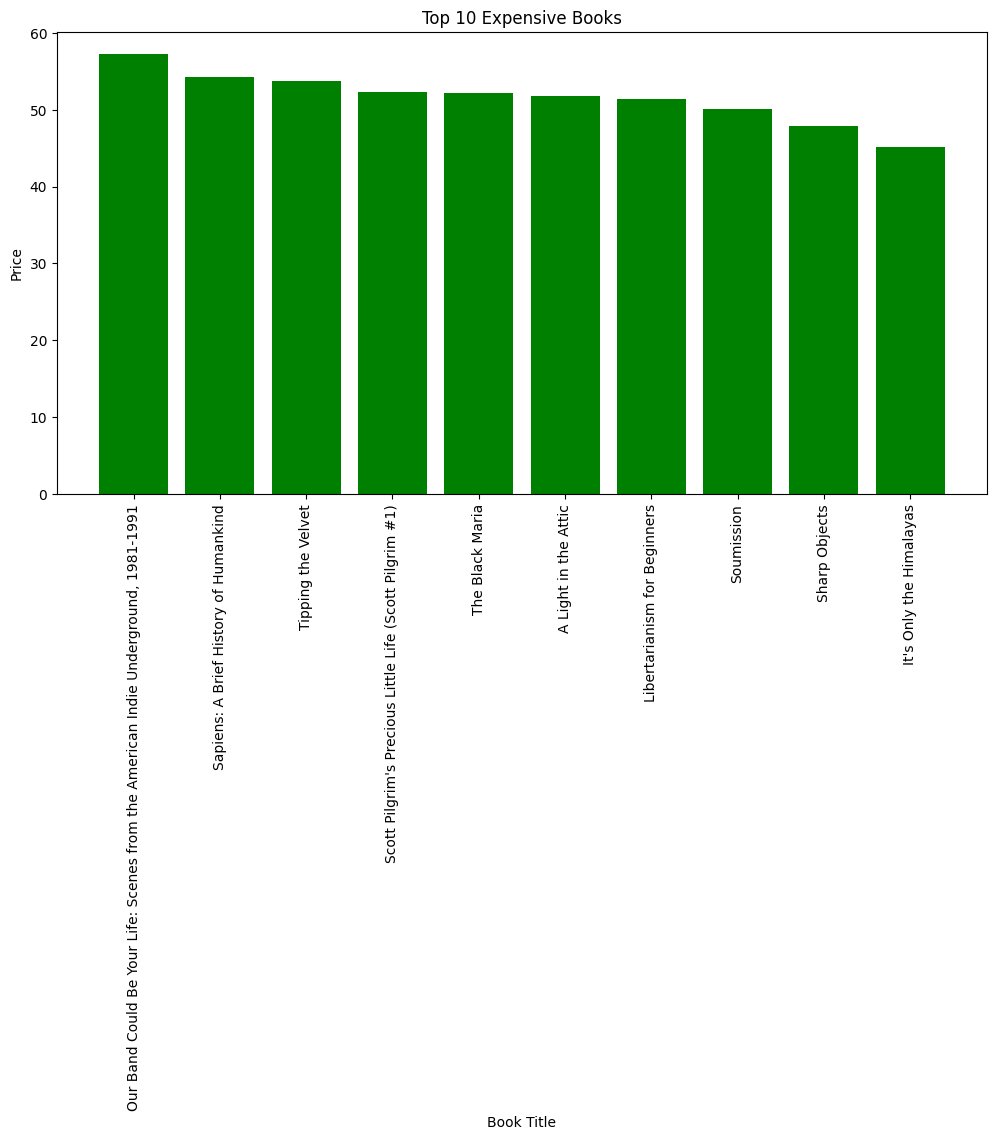

In [ ]:
exp_books = df.sort_values(by='Price', ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.bar(exp_books['Title'], exp_books['Price'], color='green')
plt.title("Top 10 Expensive Books")
plt.xlabel('Book Title')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.show()

OBSERVATIONS -
this is a price and title graph which displays top 10 most expensive books available.
A book named "Our Band Could be Your Life.." is the most expensive book with price greater than $50.
displayed by bar graph.

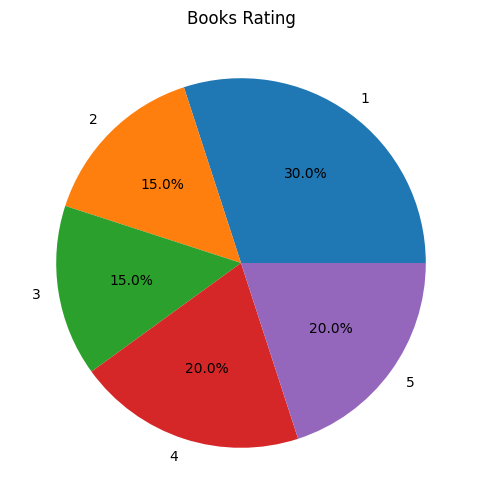

In [37]:
r = df['Rating'].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(r.values, labels=r.index, autopct = '%1.1f%%')
plt.title("Books Rating")
plt.show()

OBSERVATIONS - 
we can observe that most of the books has only 1-star rating, almost 30% books. 
where as only 20% of total books are rated 5-star by the readers.
displayed by pie chart.

CONCLUSION -
this project successfully demonstrated the process of web scraping using Python libraries like Requests, Pandas, Matplotlib and BeautifulSoup. Book data including titles, prices, rating, availability is extracted, cleaned and analysed properly. This project also explains and visualise this data graphically which provides a practical experience in handling real world web data for analysis purposes. 